# 🚗 Predicting Car Prices with Machine Learning

Welcome, data explorers! 👩‍💻👨‍💻🚀

Imagine you're browsing through a car dealership’s website and wondering — *"Why is this car more expensive than that one?"* 🤔  
Well, today **you’re the data scientist behind the scenes**, building a model that helps answer exactly that.

In this case study, you and your team will work on an **end-to-end machine learning project** to **predict car prices** based on various features like the model, year, mileage, fuel type, and more. We'll be using a real-world dataset from the automotive market — noisy, messy, and full of patterns waiting to be discovered. 🧠📊

You'll walk through the full ML pipeline:  
- Cleaning and preprocessing the data 🧹  
- Exploring the hidden relationships 🔍  
- Building and tuning regression models 🛠️  
- Evaluating how well your model performs 📈  
- And maybe... deploying it? (ambitious, but hey — dream big!)

By the end of this notebook, you’ll have built a model that can **predict the price of a car**, and more importantly, you'll understand how to tackle real-world machine learning problems from scratch.

Let’s rev up our engines and start predicting! 🏁💥


#### First, let's take a look at our dataset

In [10]:

import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/predict_prices_dataset.csv')
df.head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
5,A1,2016,13900,Automatic,32260,Petrol,30,58.9,1.4,audi
6,A6,2016,13250,Automatic,76788,Diesel,30,61.4,2.0,audi
7,A4,2016,11750,Manual,75185,Diesel,20,70.6,2.0,audi
8,A3,2015,10200,Manual,46112,Petrol,20,60.1,1.4,audi
9,A1,2016,12000,Manual,22451,Petrol,30,55.4,1.4,audi


#### 2. Explore the Dataset (EDA - Exploratory Data Analysis)
Understand the structure and content:

Shape of the dataset

Data types

Missing values

Statistical summary

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         72435 non-null  str    
 1   year          72435 non-null  int64  
 2   price         72435 non-null  int64  
 3   transmission  72435 non-null  str    
 4   mileage       72435 non-null  int64  
 5   fuelType      72435 non-null  str    
 6   tax           72435 non-null  int64  
 7   mpg           72435 non-null  float64
 8   engineSize    72435 non-null  float64
 9   Make          72435 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 5.5 MB


In [12]:
# Summary statistics
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000,72435.000000
mean,2017.073666,16579.987506,23176.517057,116.953407,55.852480,1.635650
std,2.101252,9299.218027,21331.515562,64.045533,17.114391,0.561535
min,1996.000000,99.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,10175.000000,7202.500000,30.000000,47.900000,1.200000
50%,2017.000000,14495.000000,17531.000000,145.000000,55.400000,1.600000
75%,2019.000000,20361.000000,32449.000000,145.000000,62.800000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,470.800000,6.600000


#### Let's get some insights

🔧 Year: 
- Mean year of cars is ~2017, with a range from 1996 to 2020.
- 75% of the cars are from 2016 or newer, indicating the dataset is mostly composed of recent vehicles.
- The standard deviation (~2.1 years) shows low year variability — mostly modern cars.

💰 Price
- Car prices range from as low as £495 to £145,000 — this is a huge spread, likely including luxury and budget models.
- The average price is around £16,580, with a median of £14,495, suggesting a right-skewed distribution (some very expensive outliers).

🛣️ Mileage
- Mileage spans from 0 to 323,000 miles — a massive range.
- Median mileage is around 17,531, and the mean is 23,176, again showing a right-skewed distribution (many high-mileage cars).

💸 Tax
- Tax ranges from £0 to £580, with a median of £145, which likely reflects common tax bands.
- Mean tax is ~£117, and 75% of cars fall below £145 — outliers should be reviewed here as well.

⛽ MPG (Miles per Gallon)
- Extremely wide range from 0.3 to 470.8 MPG — the upper value is almost certainly an anomaly or data entry error (possibly electric vehicles with an equivalent mpg).
- Median of 55.4 MPG, and average of ~55.85, suggesting mostly fuel-efficient vehicles.

🔧 Engine Size
- Engine sizes range from 0.0 to 6.6 liters, with median = 1.6L, which aligns with common car engines.
- Some 0.0 engine sizes might indicate missing or erroneous values.
- Values above 4.0L likely belong to high-performance/luxury cars.

#### Do we have missing values??

In [13]:
# Check for missing values
df.isnull().sum()
# df.fillna(0).count()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Make            0
dtype: int64

###### Handling Missing Values – Quick Decision Guide

---

###### 1) Identify Feature Type
- **Categorical (`make`, `model`)** → Mode, `"Unknown"`, or predictive modeling  
- **Numerical (`price`, `mileage`, `engineSize`)** → Mean/Median, group-wise stats, or regression/KNN  
- **Ordinal (e.g., condition 1–5)** → Median or interpolation  

---

###### 2) Check Missingness Percentage
- **<5%** → Simple imputation (mean/median/mode)  
- **5–30%** → Group-wise or model-based imputation  
- **>30%** → Consider dropping or advanced methods  

---

###### 3) Determine Missingness Mechanism
- **MCAR** (*Completely Random – e.g., data entry errors*) → Mean/median (num), Mode (cat)  
- **MAR** (*Depends on other features – e.g., mileage missing in new cars*) → Group-wise, Regression, or KNN  
- **MNAR** (*Depends on the value itself – e.g., high-priced cars hiding price*) → Keep as `NaN`, or add `"missing"` flag  

---

###### 4) Check Data Ordering
- **Sequential/Time-series** → FFILL/BFILL **within groups only**  
- **Unordered (typical listings)** → Prefer statistical or model-based methods; **avoid FFILL/BFILL**  

---

###### 5) Quick Reference Table

| Situation                | Recommended Method                          |
|---------------------------|---------------------------------------------|
| Categorical, low missing  | Mode or `"Unknown"` category                |
| Numerical, MCAR           | Mean or median                              |
| Numerical, MAR            | Group-wise median/mean, KNN, or regression  |
| Numerical, MNAR           | Keep as `NaN` or add `"missing"` flag       |
| Sequential data           | FFILL/BFILL within same group only          |

---

###### 6) Best Practices
✔ Analyze missingness before imputing  
✔ Group by similar characteristics (`make`, `model`) when filling  
✔ Never propagate values across unrelated groups  
✔ Test model performance **with & without** imputation  

---


#### Load dataset again to see it here

In [14]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi
...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai


##### Ok, now take am moment to inspect the data closely. Which is the target variable? -in our case, the price. What car brands do we have, models, what fuel type corresponds to what model, and so on. 
##### The best way to do this is of course, using visual types of plots! 

📊 1. Distribution of Car Prices
Shows price skewness and outliers.

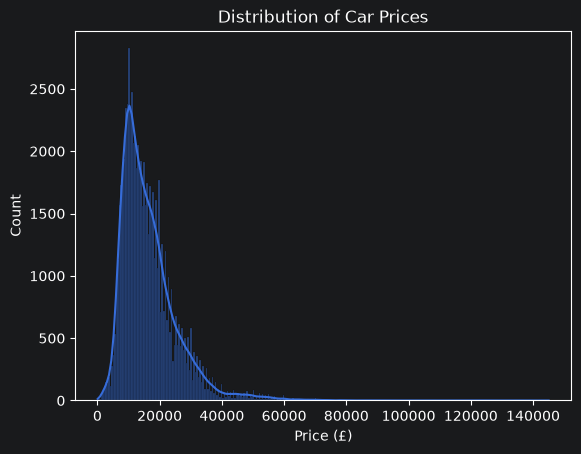

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins="auto", kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()



####  TODO: Write some conclusions 
#### This is a right skew - most data points are concentrated the left side
#### - Most cars are priced at the lower end
#### - A long tail extends to very expensive cars (£60,000–£140,000), but these are rare
#### - The mode (peak) is around £10,000–£15,000, meaning this is the most common price range
#### - Cars priced above ~£60,000 are rare outliers; they may need separate analysis if predicting or modeling prices

🧼 2. Boxplot of Price by Transmission Type
Compare prices across automatic vs manual cars.

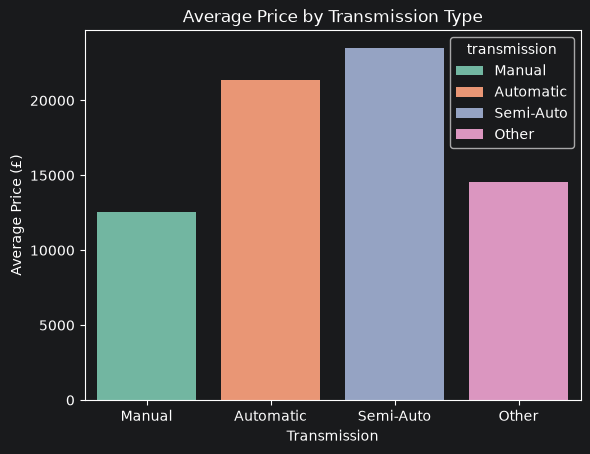

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Use 'hue' to apply the palette per category
sns.barplot(
    x='transmission',
    y='price',
    data=df,
    hue='transmission',
    palette='Set2',
    errorbar=None,              
    legend=True             
)

plt.title('Average Price by Transmission Type')
plt.ylabel('Average Price (£)')
plt.xlabel('Transmission')
plt.xticks(rotation=0)
plt.show()

####  TODO: Write some conclusions 
#### highest average price - Semi-Auto cars costs around 24k £ 
#### lowest average price - Manual cars costs around 13k £
#### automatic cars fall in between, around 17k £, this suggests that transmission type does have an impact on price, with semi-automatic cars being the most expensive on average.
#### other types of transmissions are less common and they may have different pricing dynamics, but they are not as prevalent in the dataset.




⛽ 3. Boxplot of Price by Fuel Type
Helps assess how fuel type affects car pricing.

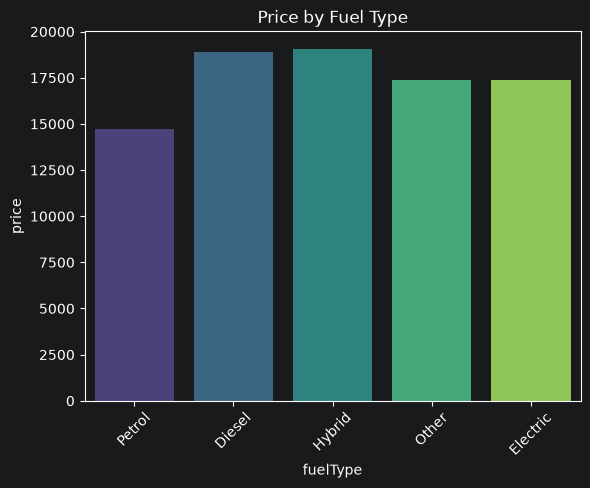

In [17]:


sns.barplot(x='fuelType', y='price', data=df, hue='fuelType',         
    palette='viridis',
    errorbar=None,              
    legend=False )
plt.title('Price by Fuel Type')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions 
#### - Petrol-fueled cars are the cheapest
#### - Hybrid-fueled cars have the highest prices
#### - Diesel-fueled cars are in between, but closer to petrol than hybrid
#### - Electric cars are also expensive, but they are less common in the dataset

🏷️ 4. Average Price per Car Make
Top 15 brands only for readability.


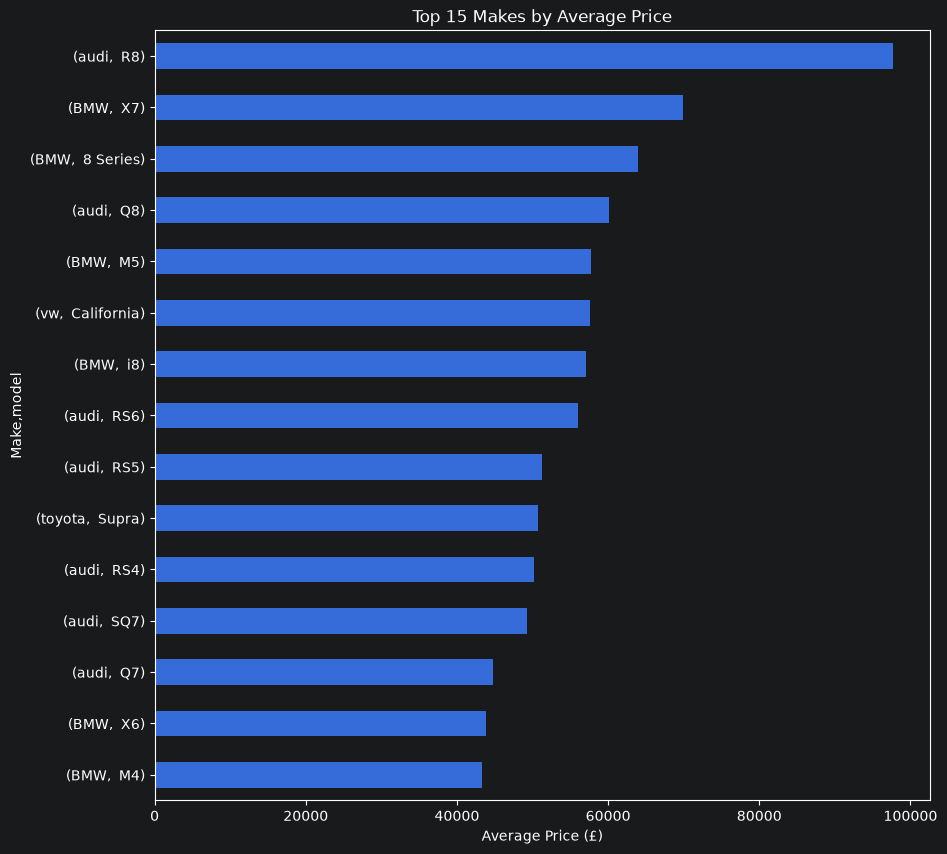

In [18]:
avg_price_by_make = df.groupby(['Make', 'model'])['price'].mean().sort_values(ascending=False).head(15)
avg_price_by_make.plot(kind='barh', figsize=(10, 10))
plt.xlabel('Average Price (£)')
plt.title('Top 15 Makes by Average Price')
plt.gca().invert_yaxis()
plt.show()

####  TODO: Write some conclusions 
#### - Audi and BMW have the highest average prices
#### - Ford has the lowest average price

---
#### Switching to models we can see that the most expensive model is audi R8

📈 5. Scatterplot of Mileage vs. Price
See depreciation pattern as mileage increases.

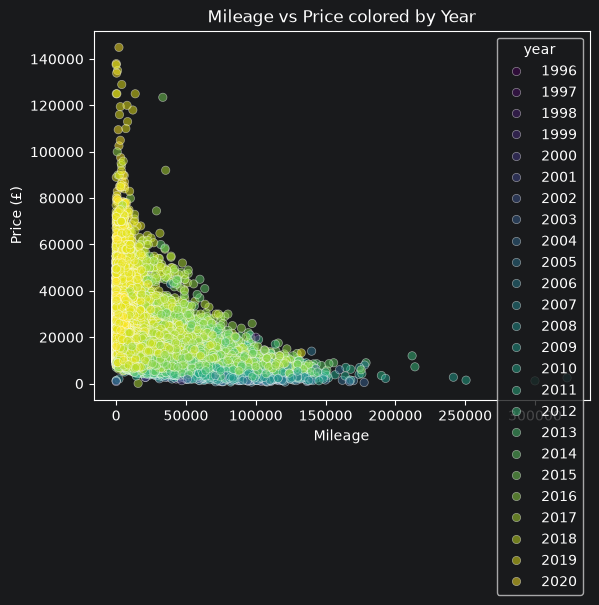

In [19]:
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.5, hue='year', palette='viridis', legend='full')
plt.title('Mileage vs Price colored by Year')
plt.xlabel('Mileage')
plt.ylabel('Price (£)')
plt.show()

####  TODO: Write some conclusions 
#### - Assigning a variable to hue map its levels to the color of the plots
#### - hue = year different colors for each year
#### - Newest cars (2018-2020) have low mileage and high prices 
#### - As the cars get older they increase in mileage, things that justify the low price
#### - High density of low priced cars
#### - Outliers: 
####      - new cars (expensive, low mileage)
####      - mid year cars (cheap, high mileage)



📅 6. Price vs Year
Understand how newer cars are priced.

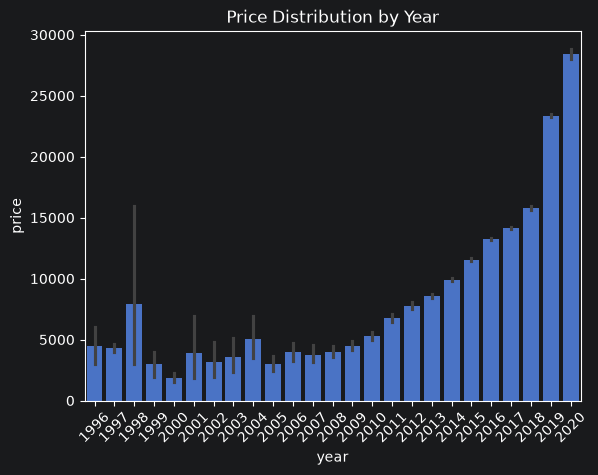

In [20]:
sns.barplot(x='year', y='price', data=df)
plt.title('Price Distribution by Year')
plt.xticks(rotation=45)
plt.show()

####  TODO: Write some conclusions
#### there exists a clear trend where newer cars are priced higher, as expected, thanks to lower mileage and better technology. However, there are some exceptions where certain older models may have higher prices due to rarity or brand value.
#### the stability of the cars fabricated between 1996 and 2010: the prices are relatively stable, with some fluctuations, but they do not show a clear upward or downward trend. This could be due to the fact that these cars have already depreciated significantly and their prices are more influenced by factors like mileage, condition, and brand reputation rather than the year of manufacture.
#### the error bars for the cars fabricated in 1997, 2001 and 2004 suggest indicate a high variability in prices, maybe caused by a mix of special editions, luxury collections, so the price for these years is not as predictable as for other years.

⚙️ 7. Engine Size vs Price
Bigger engines tend to cost more — is it true?

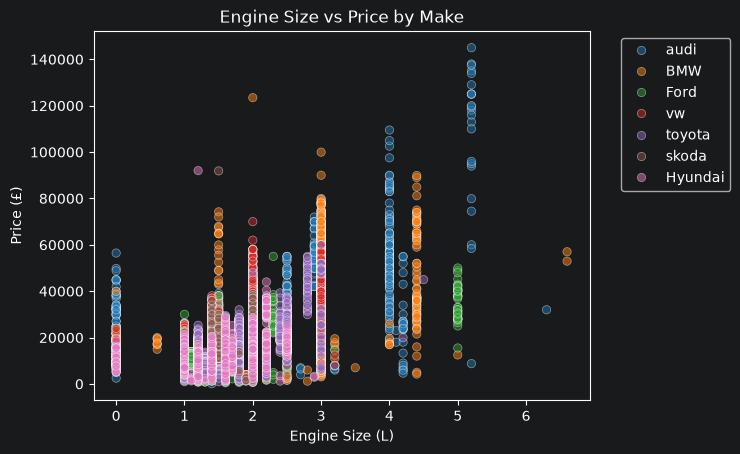

In [21]:
sns.scatterplot(x='engineSize', y='price', data=df, alpha=0.5, hue='Make', palette='tab10', legend='full')
plt.title('Engine Size vs Price by Make')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (£)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

####  TODO: Write some conclusions
#### - There is a positive correlation between engine size and price, as expected. Larger engines are typically found in more expensive vehicles.
#### - Some makes (e.g., BMW, Audi) have larger engines and higher prices, while others (e.g., Ford, Vauxhall) have smaller engines and lower prices.
#### - There are some outliners, for example, cars with engine size of 0.0, which are likely data entry errors or electric vehicles. These should be investigated further.
#### - Hyundai, Toyoto and Skoda have a smaller engine size, so lower prices, this means they are not luxury brands, but they are more affordable.

🛣️ 8. MPG vs Price
Fuel efficiency vs cost.

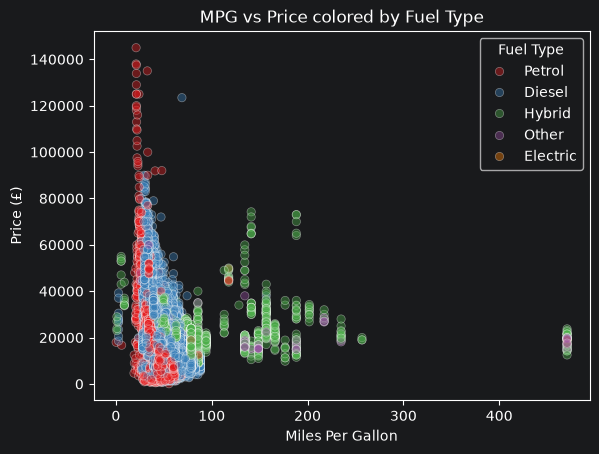

In [22]:
sns.scatterplot(x='mpg', y='price', data=df, alpha=0.4, hue='fuelType', palette='Set1')
plt.title('MPG vs Price colored by Fuel Type')
plt.xlabel('Miles Per Gallon')
plt.ylabel('Price (£)')
plt.legend(title='Fuel Type')
plt.show()

####  TODO: Write some conclusions
#### - There is a negative correlation between MPG and price, meaning that cars with higher fuel efficiency tend to be cheaper. This makes sense as high-performance or luxury cars often have lower MPG.
#### - Petrol cars tend to have lower MPG and higher prices, while diesel and hybrid cars have higher MPG and lower prices. Electric cars are outliers with very high MPG (or equivalent) and high prices.
#### - There are some outliers with extremely high MPG (e.g., >400 mpg), which are likely data entry errors or electric vehicles. These should be investigated further.


### Let's see how these are correlated to the price

📦 9. Correlation Heatmap
Find linear relationships between numeric features.

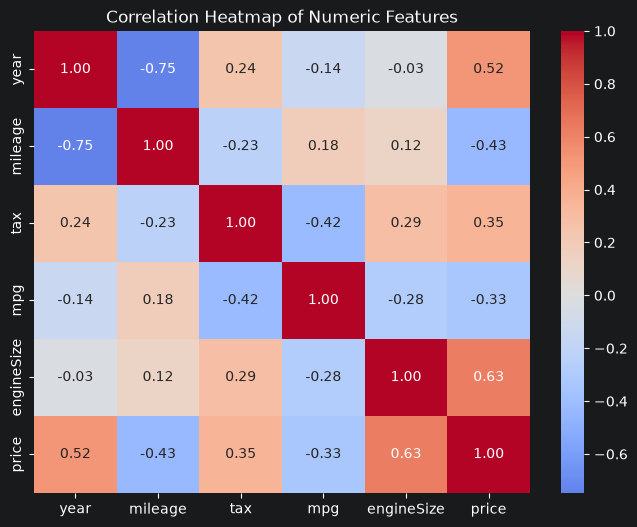

In [23]:
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [24]:
corr = df.corr(numeric_only=True)


C:\Users\StanAndaMaria\AppData\Local\Temp\ipykernel_7568\3789713215.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')


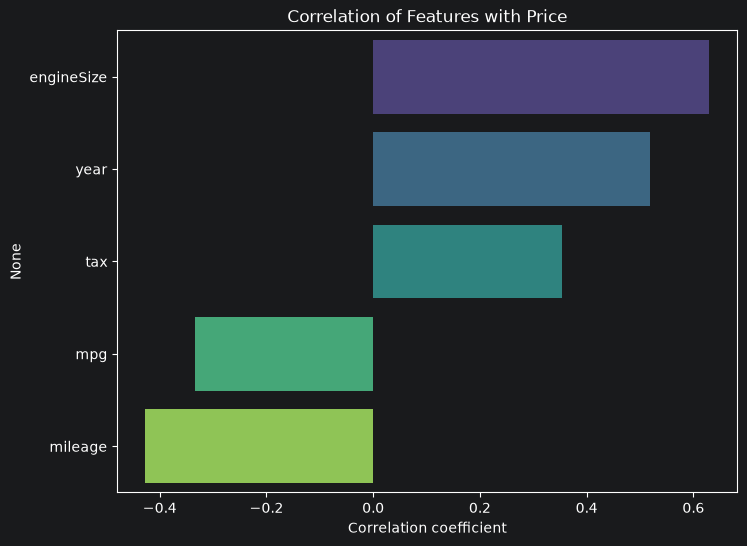

In [25]:

# Correlation with 'price' only
price_corr = corr['price'].sort_values(ascending=False)

# Drop 'price' itself for clarity
price_corr = price_corr.drop('price')

plt.figure(figsize=(8, 6))
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis')
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.show()

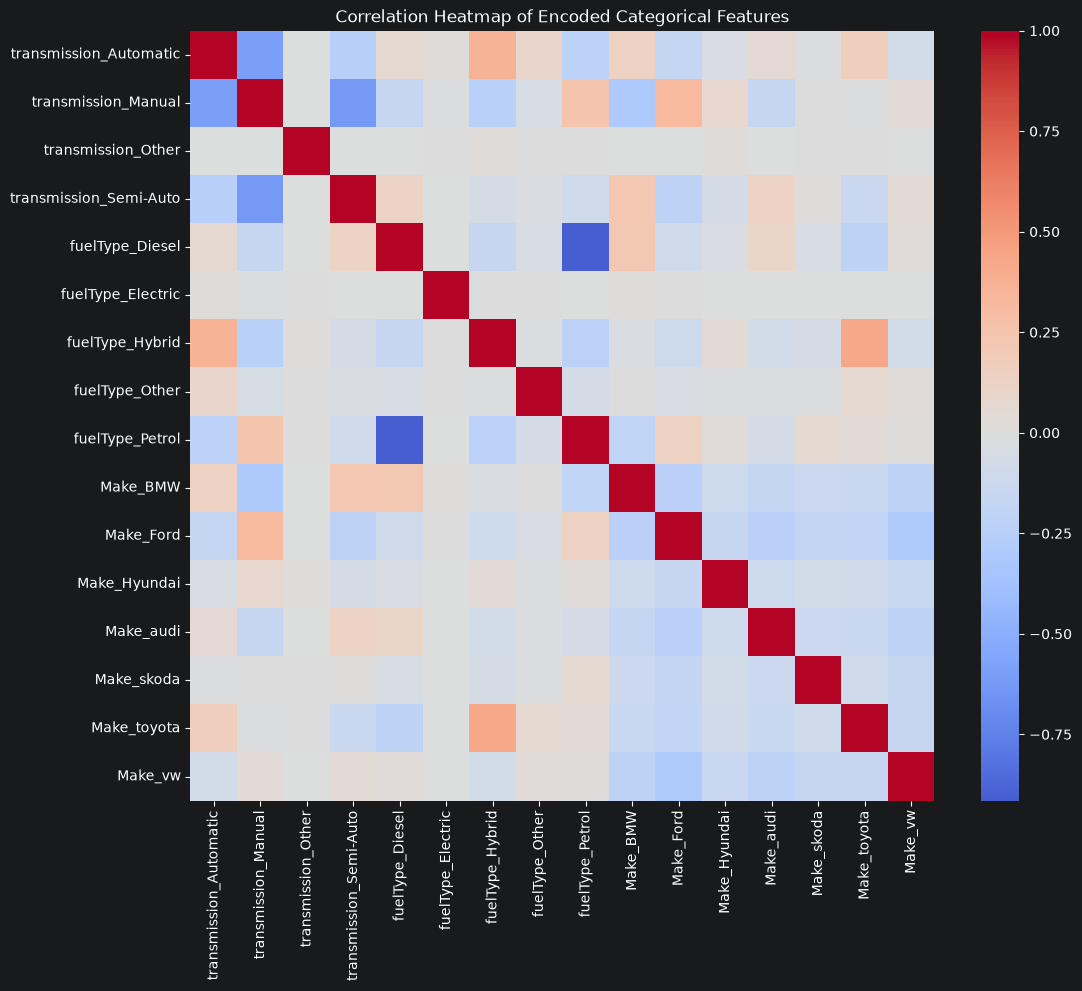

In [26]:
# Drop 'model' and encode categorical columns
df_no_model = df.drop(columns=['model'])
df_encoded = pd.get_dummies(df_no_model, columns=['transmission', 'fuelType', 'Make'])

# Select encoded categorical columns (exclude numeric)
numeric_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']
encoded_cols = [col for col in df_encoded.columns if col not in numeric_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded[encoded_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Encoded Categorical Features')
plt.show()

#### Ok, we have a lot of correlations here so we can draw a lot of conclusions. When a correlation is approaching to 1, it means that there is a strong correlation between two features, and they are directly proportional to one another. Where the correlation is close to 0, it does not indicate to much for us, no correlation. If the correlation is approaching to -1, it means that there is an inverse proportionality between those features: where one increases, the other one decreaases.

In [75]:
#### TODO: Write at least 10 conclusions based on correlations
#### From the first heatmap, we can see that:
#### 1) The strongest positive correlation with price is engineSize(0.63), meaning that larger engines tend to be more expensive.
#### 2) Year has the second strongest positive correlation with price (0.52), indicating that newer cars are generally more expensive.
#### 3) The strongest negative correlation is between year and mileage (-0.75), which makes sense because an older car will have more time to accumulate mileage.
#### 4) Mileage has a moderate negative correlation with price (-0.43), meaning that cars with higher mileage tend to be cheaper.
#### 5) Tax has a moderate negative correlation with mpg (-0.42) meaning that cars with higher fuel efficiency tend to have lower tax.
#### The second heatmap just resumes the first heatmap.
#### From the third heatmap, we can see that:
#### 6) The strongest positive correlations are between: fuelType_Hybrid and transmission_Automatic, Make_Toyota and fuelType_Hybrid, Make_Ford and transmission_Manual.
#### 7) Moderate strong positive correlations are between: transmission_Manual and fuelType_Petrol, transmission_Semi-Auto and Make_BMW, fuelType_Diesel and Make_BMW, fuelType_Petrol and transmission_Manual.
#### 8) Strongest negative correlation is between: fuelType_Petrol and fuelType_Diesel.
#### 9) Moderate negative correlations are between: transmission_Manual and transmission_Automatic, transmission_Manual and transmission_Semi-Auto.
#### 10) There are other non semnificant correlations between categorical features, but they are not as strong as the ones mentioned above, such that: Make_Ford and fuelType_petrol, fuelType_Diesel and Make_Audi etc.


### Next steps:
- Feature Engineering: create new or transformed features that may better capture relationships (e.g. : Age of car: car_age = current_year - year, Binning mileage or engineSize into ranges, Log-transform skewed data (e.g., price, mileage), Interactions (e.g., mpg × engineSize))
- Encoding Categorical Features: perfect for transmission, fuelType, Make. Decide what to do with model column (high cardinality column)
- Feature Selection:
     - You don't always want to keep everything. Good strategies include:
     - Use correlation with price (already done!)
     - SelectKBest, recursive feature elimination (RFE)
     - Model-based importance (e.g., .feature_importances_ from RandomForestRegressor)

In [78]:
#### Let's exemplify these two new features that were engineered based on already existing columns:

In [79]:
import datetime

current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2017,9
1,2016,10
2,2016,10
3,2017,9
4,2019,7


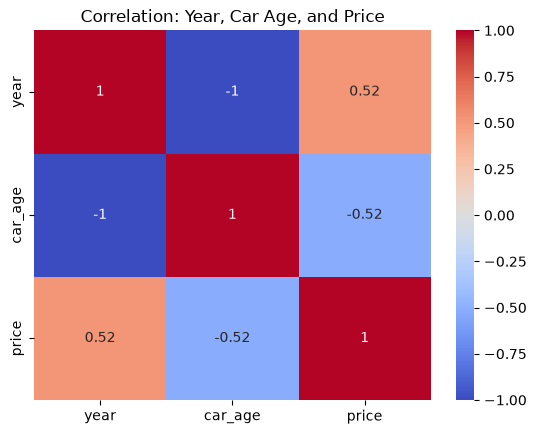

In [80]:
correlation_subset = df[['year', 'car_age', 'price']].corr()
sns.heatmap(correlation_subset, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Year, Car Age, and Price')
plt.show()

#### For example, it did not help. You can work with either car age or year, it gives the same stuff

In [81]:
# Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# Check distribution
df['mileage_bin'].value_counts()

mileage_bin
Low          28207
Very Low     23584
Medium       15994
High          4060
Very High      590
Name: count, dtype: int64

#### Create bins for mileage

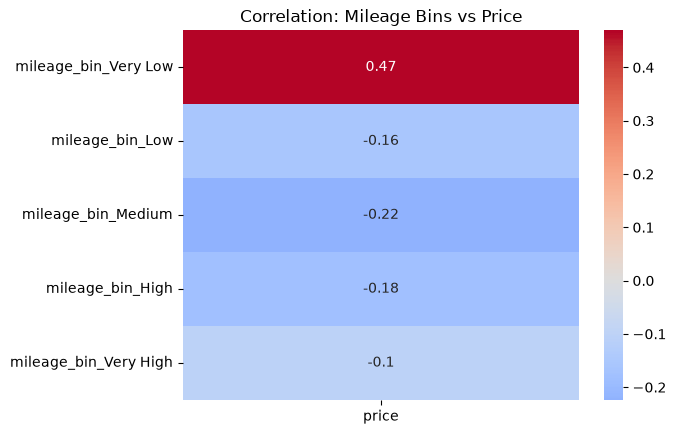

In [82]:
# 1. Define mileage bins
bins = [0, 10000, 30000, 60000, 100000, df['mileage'].max()]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['mileage_bin'] = pd.cut(df['mileage'], bins=bins, labels=labels)

# 2. One-hot encode the bin column
df_encoded_bins = pd.get_dummies(df[['mileage_bin', 'price']], drop_first=False)

# 3. Compute correlation matrix
corr_bins = df_encoded_bins.corr()

# 4. Show correlation of each bin with price
corr_with_price = corr_bins[['price']].drop('price')  # remove self-correlation

# 5. Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation: Mileage Bins vs Price')
plt.show()

#### TODO: is it helpful?
-try other one
It is partially helpful, but not as strong as the continuous mileage feature. The "Very Low" has a positive correlation with price, while the "High" and "Very High" bins have a negative correlation. However, the correlations are weaker than using the raw mileage values, which may suggest that binning loses some information. It might be better to keep mileage as a continuous variable for regression models.

Mileage per year
#Cream o noua coloana care arata cat a rulat masina pe an
#Adaugam +1 la car_age pt a evita impartirea la zero (daca mașina e din anul curent)
df['mileage_per_year'] = df['mileage'] / (df['car_age'] + 1)

#Verificam corelatia cu pretul
print(df[['mileage_per_year', 'price']].corr())

#Vizualizam
sns.heatmap(df[['mileage_per_year', 'price']].corr(), annot=True, cmap='coolwarm')
plt.title('Corelație: Mileage per Year vs Price')
plt.show()

apoi codificarea variabilelor categorice, pas critic pt intelegerea modelului de regresie.
# Transformam variabilele categorice in numere (0, 1)
df_encoded = pd.get_dummies(df, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

# Acum se poate vedea corelatia reala a tipului de combustibil cu pretul
# Selectam doar cateva coloane pentru heatmap ca sa nu fie prea mare
cols_to_check = [col for col in df_encoded.columns if 'fuelType' in col or 'price' in col]
sns.heatmap(df_encoded[cols_to_check].corr(), annot=True, cmap='coolwarm')
plt.title('Corelație: Fuel Type vs Price')
plt.show()




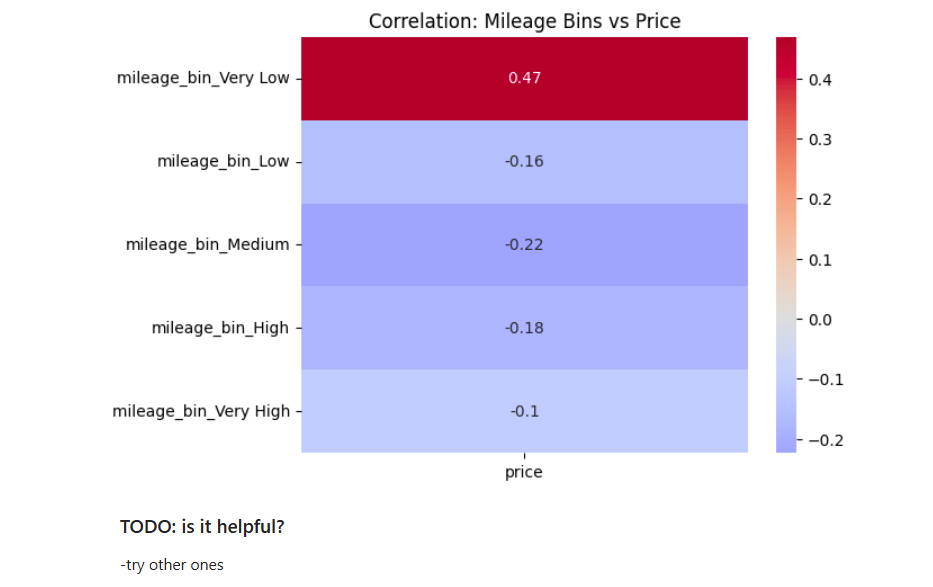

#### Let's go back to the dataset, since we have enough information

In [83]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make,car_age,mileage_bin,mileage_bin_encoded
0,A1,2017,99,Manual,15735,Petrol,150,55.4,1.4,audi,9,Low,1
1,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0,audi,10,Medium,2
2,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4,audi,10,Low,1
3,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0,audi,9,Low,1
4,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0,audi,7,Very Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,I30,2016,8680,Manual,25906,Diesel,0,78.4,1.6,Hyundai,10,Low,1
72431,I40,2015,7830,Manual,59508,Diesel,30,65.7,1.7,Hyundai,11,Medium,2
72432,I10,2017,6830,Manual,13810,Petrol,20,60.1,1.0,Hyundai,9,Low,1
72433,Tucson,2018,13994,Manual,23313,Petrol,145,44.8,1.6,Hyundai,8,Low,1


#### Categorical features need to be endoded

| Column         | Type             | Strategy                       | Notes                                    |
| -------------- | ---------------- | ------------------------------ | ---------------------------------------- |
| `transmission` | Categorical      | One-hot encoding               | Few categories                           |
| `fuelType`     | Categorical      | One-hot encoding               | Few categories                           |
| `Make`         | Categorical      | One-hot encoding               | Moderate number of brands (OK to encode) |
| `model`        | High-cardinality | Exclude or use target encoding | Too many unique values                   |
| `mileage_bin`  | Ordinal-ish      | Ordinal encoding or one-hot    | Low to high — either way works           |


In [84]:
mileage_bin_order = {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['mileage_bin_encoded'] = df['mileage_bin'].map(mileage_bin_order)

# Now create df_encoded, drop 'model' and 'mileage_bin' (keep mileage_bin_encoded)
df_encoded = df.drop(columns=['model', 'mileage_bin'])

# One-hot encode categorical variables (except mileage_bin_encoded which is numeric now)
df_encoded = pd.get_dummies(df_encoded, columns=['transmission', 'fuelType', 'Make'], drop_first=True)

In [89]:
df_encoded

,year,price,mileage,tax,mpg,engineSize,car_age,mileage_bin_encoded,transmission_Manual,transmission_Other,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,9,1,True,False,...,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,10,2,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,10,1,True,False,...,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,9,1,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,7,0,True,False,...,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,10,1,True,False,...,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,11,2,True,False,...,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,9,1,True,False,...,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,8,1,True,False,...,False,False,False,True,False,True,False,False,False,False


#### Feature selection:  I will drop car_age since it is not helpful and also model because it has that huge cardinality

#### We have to decide to use mileage or binned column, mileage_bin_encoded. For now, we will stick to the original column

In [90]:
columns_to_drop = ['model', 'car_age', 'mileage_bin_encoded']  
df_clean = df_encoded.drop(columns=columns_to_drop, errors='ignore')
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
1,2016,16500,36203,20,64.2,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
2,2016,11000,29946,30,55.4,1.4,True,False,False,False,False,False,True,False,False,True,False,False,False
3,2017,16800,25952,145,67.3,2.0,False,False,False,False,False,False,False,False,False,True,False,False,False
4,2019,17300,1998,145,49.6,1.0,True,False,False,False,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,True,False,False,False,False,False,False,False,True,False,False,False,False
72431,2015,7830,59508,30,65.7,1.7,True,False,False,False,False,False,False,False,True,False,False,False,False
72432,2017,6830,13810,20,60.1,1.0,True,False,False,False,False,False,True,False,True,False,False,False,False
72433,2018,13994,23313,145,44.8,1.6,True,False,False,False,False,False,True,False,True,False,False,False,False


In [91]:
bool_cols = df_clean.select_dtypes(include=['bool']).columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

In [92]:
df_clean

,year,price,mileage,tax,mpg,engineSize,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
0,2017,99,15735,150,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
1,2016,16500,36203,20,64.2,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,2016,11000,29946,30,55.4,1.4,1,0,0,0,0,0,1,0,0,1,0,0,0
3,2017,16800,25952,145,67.3,2.0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,2019,17300,1998,145,49.6,1.0,1,0,0,0,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72430,2016,8680,25906,0,78.4,1.6,1,0,0,0,0,0,0,0,1,0,0,0,0
72431,2015,7830,59508,30,65.7,1.7,1,0,0,0,0,0,0,0,1,0,0,0,0
72432,2017,6830,13810,20,60.1,1.0,1,0,0,0,0,0,1,0,1,0,0,0,0
72433,2018,13994,23313,145,44.8,1.6,1,0,0,0,0,0,1,0,1,0,0,0,0


#### TODO: Consider improvements like Standardization or Normalization:

| Technique           | What it does                            | When to use                                                                                                                                                         |
| ------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Standardization** | Centers data to mean=0, std=1 (z-score) | When features have different units/scales, and your model assumes normality or is sensitive to scale (e.g., linear regression, logistic regression, SVM, k-NN, PCA) |
| **Normalization**   | Scales data to \[0,1] range             | When you want features in same scale but not necessarily centered, often useful for neural networks, distance-based models                                          |


# Next Steps for Your ML Pipeline

### 1. Split data into training and testing sets
- Use `train_test_split` (e.g., 80% train, 20% test) to evaluate your model’s performance on unseen data.

In [1]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

NameError: name 'df_clean' is not defined

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


### 2. (Optional) Further feature engineering or selection
- Try feature importance or recursive elimination to reduce noise.
- Experiment with polynomial features or interaction terms if it makes sense.

### 3. Choose machine learning model(s)
- Start simple: Linear Regression, Decision Trees, Random Forest, Gradient Boosting.
- For regression, consider models like:  
  - Linear Regression  
  - RandomForestRegressor  
  - XGBoost / LightGBM  
  - Support Vector Regression (SVR)

In [39]:
# Initialize and train Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)


In [6]:
### 4. Cross-validation
##- Use K-Fold Cross Validation (e.g., 5 or 10 folds) on training set for robust performance estimation.
##- Tune hyperparameters via grid search or random search within CV.

### TODO: perform cross-validation and choose best model! Play with parameters
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
df = pd.read_csv('./dataset/predict_prices_dataset.csv')
# pregatim datele si facem split la ele
#datele text le transformama in 0 si 1 pt a fi intelese de model
df_clean = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType', 'Make'], drop_first=True)

#ne axam pe pretul masinii
X = df_clean.drop(columns=['price'])
y = df_clean['price']

#impartim datele: 80% antrenament si 20% testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dimensiuni:", X_train.shape, X_test.shape)

#initializarea modelului
rf = RandomForestRegressor(random_state=42)

#cross validation propriu zis
#definim parametrii cu care lucram
param_grid = {
    'n_estimators': [50],
    'max_depth': [10]
}

#Configuram GridSearchCV (cv=3 => 3 partitii de validare cross)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Folosește tot procesorul pentru a rula rapid
)

print("Se cauta cei mai buni parametri... (poate dura un minut)")
grid_search.fit(X_train, y_train)

print("Cei mai buni parametri gasiti:", grid_search.best_params_)

#antrenare model final
#extragem cel mai bun model gasit de grid_search
best_rf = grid_search.best_estimator_

#plsu: vedem ce acuratete avem
y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Eroarea pe datele nevazute: £{rmse:.2f}")

Dimensiuni: (57948, 163) (14487, 163)
Se cauta cei mai buni parametri... (poate dura un minut)
Cei mai buni parametri gasiti: {'max_depth': 10, 'n_estimators': 50}
Eroarea pe datele nevazute: £2590.66


### 5. Train final model on full training data
- Once hyperparameters are set, train model on all training data.

In [40]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o


### 6. Evaluate on test data
- Predict on test set.
- Calculate key metrics like:  
  - MAE (Mean Absolute Error)  
  - RMSE (Root Mean Squared Error)  
  - R² (Coefficient of Determination)


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

MAE: 1322.35
RMSE: 2322.26
R²: 0.939


MAE (Mean Absolute Error) = 1321.57
On average, your model's predicted car prices are off by about $1,322 from the actual prices. This is a direct measure of average prediction error in the same units as price.

RMSE (Root Mean Squared Error) = 2323.89
RMSE penalizes larger errors more than MAE because it squares the errors before averaging. An RMSE of ~$2,324 means larger errors exist, but overall the predictions are quite close. RMSE is more sensitive to outliers.

R² (Coefficient of Determination) = 0.939
This means your model explains about 93.9% of the variance in car prices. The closer to 1, the better the model fits the data. So 0.939 is excellent — your model predicts prices very well.

### 7. Visualize results
- Plot predicted vs actual prices scatter plot.
- Residual plots to check errors.
- Feature importance plots (for tree-based models).
- Learning curves if needed (to check for overfitting/underfitting).

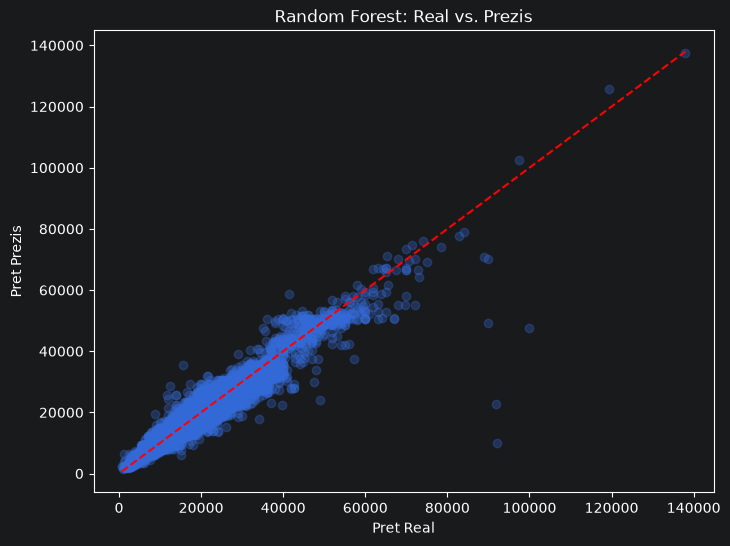

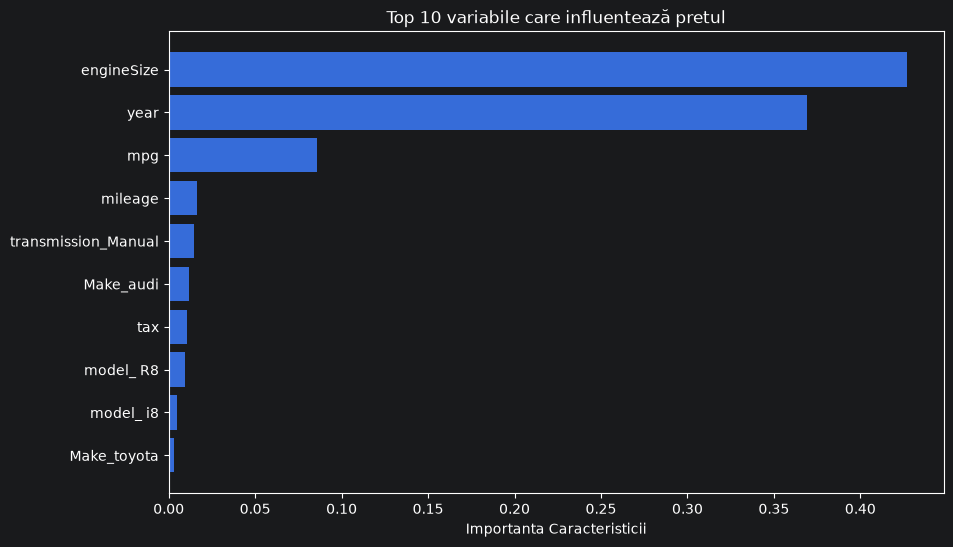

In [9]:
# 1. Scatter plot: Real vs. Prezis
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Pret Real")
plt.ylabel("Pret Prezis")
plt.title("Random Forest: Real vs. Prezis")
plt.show()

# 2. Feature Importance (Ce conteaza cel mai mult pentru pret?)
importances = best_rf.feature_importances_
# Sa luam doar top 10 cele mai importante variabile
indices = np.argsort(importances)[-10:]
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Importanta Caracteristicii")
plt.title("Top 10 variabile care influentează pretul")
plt.show()

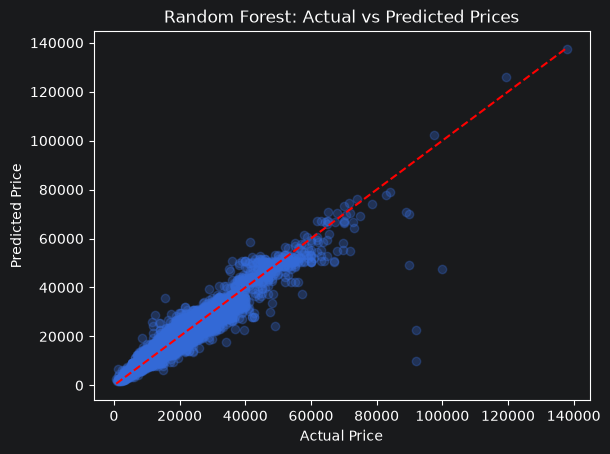

In [8]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#### TODO: How well it fit the regression line?
the majority of the poins are densely concentrated around the red line, which represents a good prediction. the linear trend of following the red line closely, confirms that The random forest model captures the relationship between car features and the price. there are some points further away the line, indicating that the model is slightly less accurate for extremely expensive or rare cars, but these represent a small portion of the total data

In [10]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()


NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.










### 8. Interpret and report
- Summarize model performance.
- Note any limitations or areas for improvement.

### 9. (Optional) Model improvement
- Try more advanced feature engineering.
- Try ensemble methods or stacking.
- Use domain knowledge for custom features.

### 10. Deployment (if needed)
- Prepare pipeline for new data.
- Save model using `joblib` or `pickle`.


## TODO: Find the next notebook here in Regression folder, it contains a dataset about house pricings in the USA. Perform Regression and all the learned techniques on it!!! :) Have fun !